<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/LSTM04_Nonlinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# make the original data
series = np.sin((0.1*np.arange(400))**2)

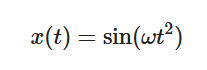

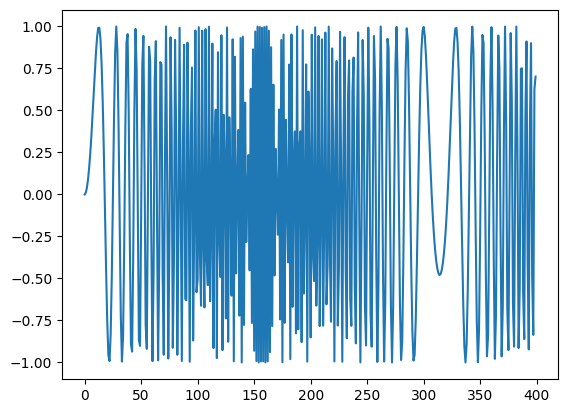

In [4]:
# plot it
plt.plot(series)
plt.show()

In [6]:
import numpy as np  # operacje na tablicach # np
import plotly.graph_objects as go  # interaktywne wykresy # plotly

series_np = np.asarray(series)  # upewniamy się, że to numpy array 1D # safety
t = np.arange(series_np.shape[0])  # oś czasu jako indeks próbek 0..N-1 # x-axis

fig = go.Figure()  # tworzymy obiekt wykresu # figure
fig.add_trace(go.Scatter(x=t, y=series_np, mode="lines", name="series"))  # dodajemy linię sygnału # trace

fig.update_layout(  # ustawienia wyglądu wykresu # layout
    template="plotly_dark",  # ciemny motyw # dark mode
    title="Series (chirp): sin((0.1*t)^2)",  # tytuł # title
    xaxis_title="t (sample index)",  # opis osi X # x label
    yaxis_title="value",  # opis osi Y # y label
)

fig.show()  # wyświetlamy wykres # show


In [7]:
### build the dataset
# let's see if we can use T past values to predict the next value
T = 10
D = 1
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T) # make it N x T
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (390, 10) Y.shape (390,)


In [9]:
### try autoregressive linear model
i = Input(shape=(T,))
x = Dense(1)(i)
model = Model(i, x)
model.compile(
  loss='mse',
  optimizer=Adam(learning_rate=0.01),
)

# train the RNN
r = model.fit(
  X[:-N//2], Y[:-N//2],
  epochs=80,
  validation_data=(X[-N//2:], Y[-N//2:]),
)

Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.3588 - val_loss: 2.2075
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3259 - val_loss: 1.8994
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0448 - val_loss: 1.6264
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9585 - val_loss: 1.4167
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8627 - val_loss: 1.2509
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7496 - val_loss: 1.1148
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7364 - val_loss: 1.0067
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6487 - val_loss: 0.9182
Epoch 9/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6280 - val_loss: 0.8322
Epoch 10/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5750 - val_loss: 0.7447
Epoch 11/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5658 - val_loss: 0.6980
Epoch 12/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5103 - val_loss: 0.6553
E

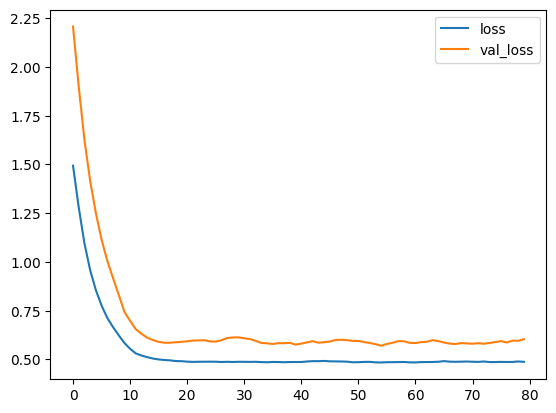

In [10]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(390, 1)


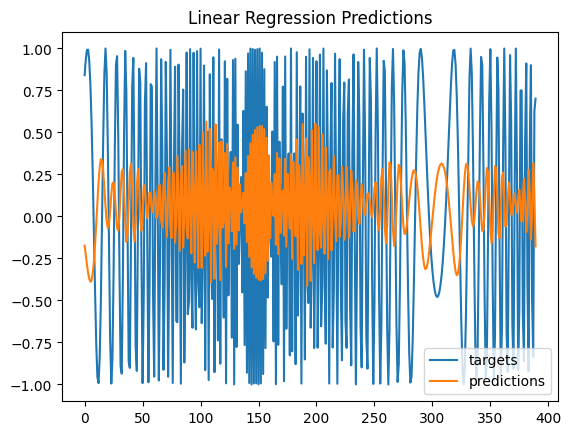

In [11]:
# One-step forecast using true targets
# Note: even the one-step forecast fails badly
outputs = model.predict(X)
print(outputs.shape)
predictions = outputs[:,0]

plt.plot(Y, label='targets')
plt.plot(predictions, label='predictions')
plt.title("Linear Regression Predictions")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

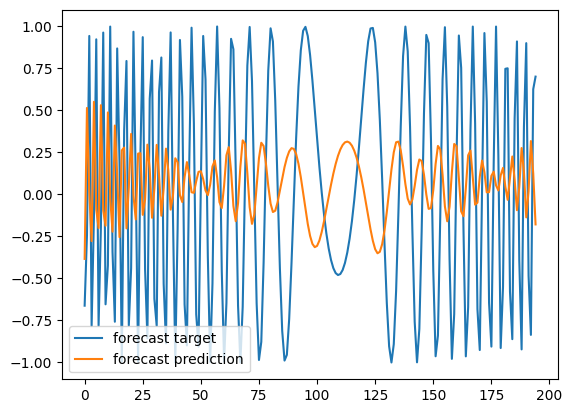

In [12]:
# This is the code we had before - it does the same thing

# One-step forecast using true targets

validation_target = Y[-N//2:]
validation_predictions = []

# index of first validation input
i = -N//2

while len(validation_predictions) < len(validation_target):
  p = model.predict(X[i].reshape(1, -1))[0,0] # 1x1 array -> scalar
  i += 1

  # update the predictions list
  validation_predictions.append(p)

plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

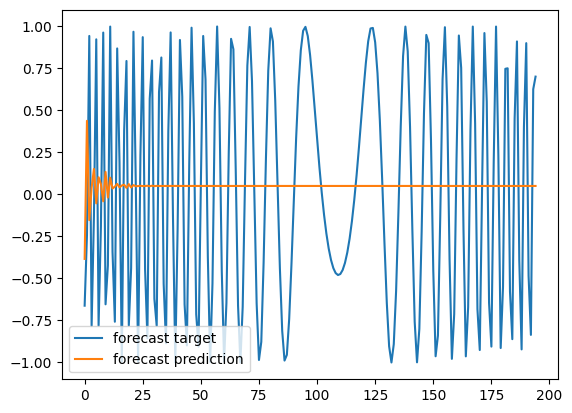

In [13]:
# Multi-step forecast
validation_target = Y[-N//2:]
validation_predictions = []

# first validation input
last_x = X[-N//2] # 1-D array of length T

while len(validation_predictions) < len(validation_target):
  p = model.predict(last_x.reshape(1, -1))[0,0] # 1x1 array -> scalar

  # update the predictions list
  validation_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

Terrible forecast of linear model

In [14]:
### Now try RNN/LSTM model
X = X.reshape(-1, T, 1) # make it N x T x D

# make the RNN
i = Input(shape=(T, D))
x = LSTM(10)(i)
x = Dense(1)(x)
model = Model(i, x)
model.compile(
  loss='mse',
  optimizer=Adam(learning_rate=0.05),
)

# train the RNN
r = model.fit(
  X[:-N//2], Y[:-N//2],
  batch_size=32,
  epochs=200,
  validation_data=(X[-N//2:], Y[-N//2:]),
)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.5541 - val_loss: 0.5376
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5148 - val_loss: 0.5129
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5063 - val_loss: 0.5314
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4780 - val_loss: 0.5477
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4332 - val_loss: 0.5900
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4232 - val_loss: 0.4234
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2789 - val_loss: 0.3354
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1885 - val_loss: 0.3299
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1821 - val_loss: 0.2676
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1280 - val_loss: 0.2553
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1078 - val_loss: 0.2055
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0902 - val_lo

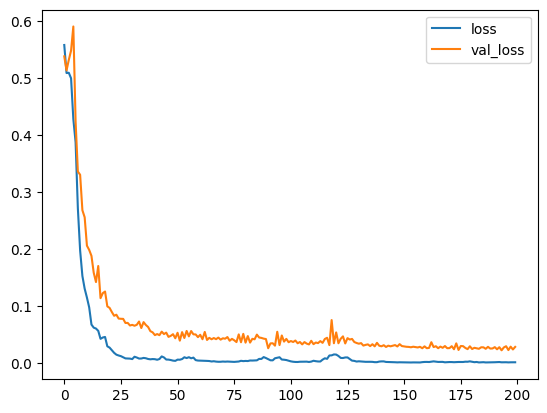

In [15]:
# plot some data
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(390, 1)


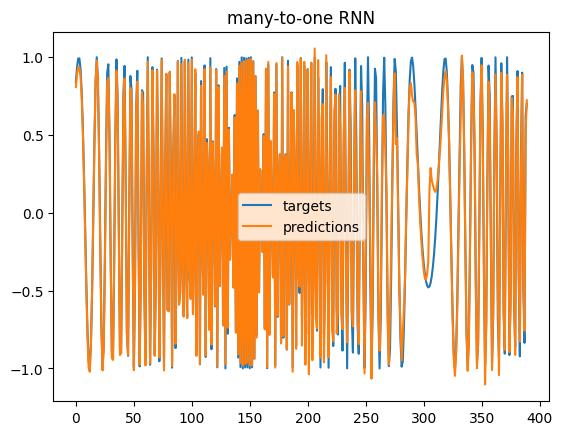

In [16]:
# One-step forecast using true targets
outputs = model.predict(X)
print(outputs.shape)
predictions = outputs[:,0]

plt.plot(Y, label='targets')
plt.plot(predictions, label='predictions')
plt.title("many-to-one RNN")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

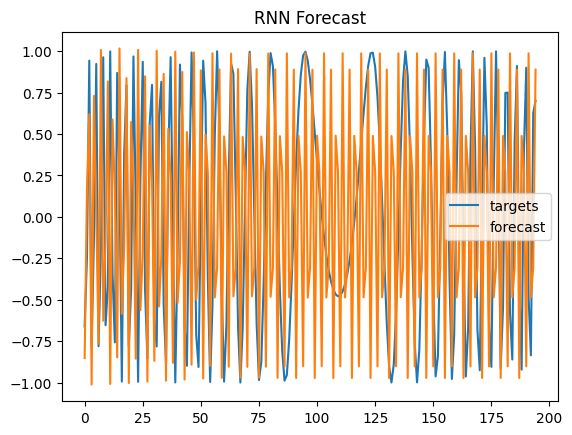

In [18]:
# Multi-step forecast
forecast = []
input_ = X[-N//2]
while len(forecast) < len(Y[-N//2:]):
  # Reshape the input_ to N x T x D
  f = model.predict(input_.reshape(1, T, 1))[0,0]
  forecast.append(f)

  # make a new input with the latest forecast
  input_ = np.roll(input_, -1)
  input_[-1] = f

plt.plot(Y[-N//2:], label='targets')
plt.plot(forecast, label='forecast')
plt.title("RNN Forecast")
plt.legend()
plt.show()

Projekt lepszej LSTM

In [21]:
# Foreword  # stroimy LSTM pod 1-step forecast: normalizacja -> 1-2 warstwy LSTM -> gęsta głowica -> wyjście 1
# Why  # tanh (domyślne) jest stabilniejsze niż relu w RNN, mniejszy LR, LayerNorm i clipnorm stabilizują trening

!pip install keras-tuner # Install keras-tuner
import tensorflow as tf  # TF/Keras # tf
import keras_tuner as kt  # tuner hiperparametrów # kt
from tensorflow.keras import Model  # model # Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization  # warstwy # layers
from tensorflow.keras.optimizers import Adam  # optymalizator # Adam
from tensorflow.keras.regularizers import l2  # regularyzacja # l2

def build_lstm_model(hp):  # funkcja budująca model pod tuner # build fn
    units1 = hp.Choice("units1", [16, 32, 64, 128])  # liczba jednostek w 1. LSTM # units
    units2 = hp.Choice("units2", [0, 16, 32, 64])  # 0 = bez 2. warstwy, inaczej druga LSTM # optional 2nd
    drop1  = hp.Float("drop1", 0.0, 0.4, step=0.1)  # dropout wejść LSTM # dropout
    rdrop1 = hp.Float("rdrop1", 0.0, 0.3, step=0.1)  # dropout rekurencyjny # rec dropout
    dense_u = hp.Choice("dense_u", [0, 16, 32, 64])  # 0 = bez gęstej głowicy, inaczej Dense # head units
    l2reg  = hp.Choice("l2reg", [0.0, 1e-6, 1e-5, 1e-4])  # regularyzacja # l2
    lr     = hp.Choice("lr", [1e-4, 3e-4, 1e-3, 3e-3])  # sensowny LR dla RNN # lr

    i = Input(shape=(T, 1))  # wejście sekwencji (T kroków, 1 cecha) # input
    x = LayerNormalization()(i)  # stabilizacja skali/offsetu w czasie # norm

    x = LSTM(  # 1. LSTM # lstm1
        units1,  # liczba jednostek # units
        return_sequences=(units2 != 0),  # jeśli ma być 2. LSTM to zwracamy sekwencję # return seq
        dropout=drop1,  # dropout wejść # dropout
        recurrent_dropout=rdrop1,  # dropout rekurencyjny # rdrop
        kernel_regularizer=l2(l2reg) if l2reg > 0 else None  # L2 jeśli ustawione # l2
    )(x)  # aplikujemy na wejście # apply

    if units2 != 0:  # opcjonalna 2. warstwa LSTM # optional
        x = LSTM(  # 2. LSTM # lstm2
            units2,  # mniejsza/porównywalna warstwa # units2
            return_sequences=False,  # na końcu bierzemy stan końcowy # last state
            dropout=hp.Float("drop2", 0.0, 0.4, step=0.1),  # dropout # drop2
            recurrent_dropout=hp.Float("rdrop2", 0.0, 0.3, step=0.1),  # rdrop # rdrop2
            kernel_regularizer=l2(l2reg) if l2reg > 0 else None  # L2 # l2
        )(x)  # apply # apply

    if dense_u != 0:  # opcjonalna gęsta głowica # dense head
        x = Dense(dense_u, activation="relu")(x)  # nieliniowa głowica # relu head
        x = Dropout(hp.Float("drop_head", 0.0, 0.5, step=0.1))(x)  # dropout głowicy # head drop

    o = Dense(1)(x)  # wyjście regresyjne (1 liczba) # output

    model = Model(i, o)  # składamy model # model
    model.compile(  # kompilacja # compile
        loss="mse",  # MSE # mse
        optimizer=Adam(learning_rate=lr, clipnorm=1.0)  # clipnorm stabilizuje gradienty RNN # adam
    )  # end compile # end

    return model  # zwrot modelu # return

tuner = kt.Hyperband(  # tuner Hyperband (szybszy niż grid) # tuner
    build_lstm_model,  # funkcja budująca # build
    objective="val_loss",  # minimalizujemy błąd walidacji # objective
    max_epochs=60,  # max epok w rundach # max ep
    factor=3,  # agresywność eliminacji słabych konfiguracji # factor
    directory="kt_dir",  # katalog wyników # dir
    project_name="lstm_1step"  # nazwa projektu # name
)

callbacks = [  # callbacki stabilizujące trening # callbacks
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),  # stop gdy brak poprawy # ES
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)  # zmniejsz LR gdy stoi # RLR
]

tuner.search(  # start strojenia # search
    X[:-N//2], Y[:-N//2],  # train (czasowo) # train
    validation_data=(X[-N//2:], Y[-N//2:]),  # val (czasowo) # val
    epochs=120,  # limit epok (Hyperband i tak tnie) # epochs
    batch_size=32,  # batch # batch
    callbacks=callbacks,  # stabilizacja # cb
    verbose=1  # log # verbose
)

best_model = tuner.get_best_models(1)[0]  # najlepszy model # best


Trial 90 Complete [00h 00m 24s]
val_loss: 0.46667981147766113

Best val_loss So Far: 0.4666796624660492
Total elapsed time: 00h 21m 27s


In [22]:
# Foreword  # bierzemy najlepsze hiperparametry z tunera i budujemy finalny model "na sztywno" (reproducible)
# Why  # best_model z tunera bywa OK, ale final_model z parametrami = pełna kontrola + łatwe odtworzenie # reproducibility

import numpy as np  # numeryka # np
import tensorflow as tf  # TF/Keras # tf
from tensorflow.keras import Model  # model # Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization  # warstwy # layers
from tensorflow.keras.optimizers import Adam  # optymalizator # Adam
from tensorflow.keras.regularizers import l2  # regularyzacja # l2

best_hp = tuner.get_best_hyperparameters(1)[0]  # najlepszy zestaw hiperparametrów # best hp

# --- wyciągamy parametry (z fallbackami, bo część istnieje tylko gdy units2!=0 / dense_u!=0) # params
units1  = best_hp.get("units1")  # units # units1
units2  = best_hp.get("units2")  # optional 2nd # units2
drop1   = best_hp.get("drop1")  # dropout # drop1
rdrop1  = best_hp.get("rdrop1")  # recurrent dropout # rdrop1
dense_u = best_hp.get("dense_u")  # head units # dense_u
l2reg   = best_hp.get("l2reg")  # L2 # l2reg
lr      = best_hp.get("lr")  # learning rate # lr

drop2   = best_hp.get("drop2") if "drop2" in best_hp.values else 0.0  # dropout 2nd # drop2
rdrop2  = best_hp.get("rdrop2") if "rdrop2" in best_hp.values else 0.0  # rec dropout 2nd # rdrop2
drop_head = best_hp.get("drop_head") if "drop_head" in best_hp.values else 0.0  # head drop # drop_head

print("BEST HP:", {  # szybki podgląd # print
    "units1": units1, "units2": units2, "drop1": drop1, "rdrop1": rdrop1,
    "dense_u": dense_u, "l2reg": l2reg, "lr": lr,
    "drop2": drop2, "rdrop2": rdrop2, "drop_head": drop_head
})  # end print # end

def build_final_lstm(T):  # budowa finalnego modelu # build final
    i = Input(shape=(T, 1))  # wejście sekwencji # input
    x = LayerNormalization()(i)  # stabilizacja # norm

    x = LSTM(  # 1st LSTM # lstm1
        units1,  # units # units
        return_sequences=(units2 != 0),  # zwróć sekwencję jeśli ma być 2nd LSTM # return seq
        dropout=drop1,  # dropout # drop
        recurrent_dropout=rdrop1,  # rec dropout # rdrop
        kernel_regularizer=l2(l2reg) if l2reg and l2reg > 0 else None  # L2 # l2
    )(x)  # apply # apply

    if units2 != 0:  # jeśli tuner wybrał 2nd LSTM # if
        x = LSTM(  # 2nd LSTM # lstm2
            units2,  # units2 # units2
            return_sequences=False,  # ostatni stan # last state
            dropout=drop2,  # dropout # drop2
            recurrent_dropout=rdrop2,  # rec dropout # rdrop2
            kernel_regularizer=l2(l2reg) if l2reg and l2reg > 0 else None  # L2 # l2
        )(x)  # apply # apply

    if dense_u != 0:  # jeśli tuner dodał gęstą głowicę # if
        x = Dense(dense_u, activation="relu")(x)  # head # head
        x = Dropout(drop_head)(x)  # head dropout # head drop

    o = Dense(1)(x)  # wyjście regresyjne # output
    m = Model(i, o)  # model # model
    m.compile(  # compile # compile
        loss="mse",  # mse # mse
        optimizer=Adam(learning_rate=lr, clipnorm=1.0)  # Adam + clipnorm # opt
    )
    return m  # return # return

final_model = build_final_lstm(T)  # finalny model # final
final_model.summary()  # podgląd architektury # summary

# --- trening finalnego modelu (opcjonalnie; jak już masz best_model wytrenowany, możesz pominąć) # train
final_callbacks = [  # callbacki # callbacks
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),  # ES # ES
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)  # RLR # RLR
]

final_hist = final_model.fit(  # fit # fit
    X[:-N//2], Y[:-N//2],  # train # train
    validation_data=(X[-N//2:], Y[-N//2:]),  # val # val
    epochs=200,  # max epok # epochs
    batch_size=32,  # batch # batch
    callbacks=final_callbacks,  # cb # cb
    verbose=1  # log # verbose
)


BEST HP: {'units1': 32, 'units2': 16, 'drop1': 0.0, 'rdrop1': 0.2, 'dense_u': 0, 'l2reg': 0.0, 'lr': 0.0003, 'drop2': 0.0, 'rdrop2': 0.2, 'drop_head': 0.4}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 10, 1)          │             2 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,507 (29.32 KB)

 Trainable params: 7,507 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - loss: 0.5328 - val_loss: 0.4670 - learning_rate: 3.0000e-04
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5176 - val_loss: 0.4670 - learning_rate: 3.0000e-04
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5256 - val_loss: 0.4669 - learning_rate: 3.0000e-04
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.5285 - val_loss: 0.4669 - learning_rate: 3.0000e-04
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5465 - val_loss: 0.4668 - learning_rate: 3.0000e-04
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5569 - val_loss: 0.4667 - learning_rate: 3.0000e-04
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5000 - val_loss: 0.4667 - learning_rate: 3.0000e-04
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5255 - val_loss: 0.4667 - learning_rate: 3.0000e-04
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5501 - val_loss: 0.4668 - learning_rate: 3

In [23]:
# Foreword  # wykresy treningu z Keras History: loss i (opcjonalnie) accuracy w Plotly dark # why: szybka diagnostyka uczenia

import numpy as np  # wektory epok # np
import plotly.graph_objects as go  # wykresy # plotly

hist_obj = None  # uchwyt na History # init
for name in ["final_hist", "r", "history"]:  # typowe nazwy obiektu History # candidates
    if name in globals():  # sprawdzamy czy zmienna istnieje # exists
        hist_obj = globals()[name]  # bierzemy pierwszą znalezioną # pick
        break  # kończymy szukanie # break

if hist_obj is None:  # brak obiektu History # no history
    raise NameError("Nie widzę obiektu History (np. r albo final_hist). Najpierw uruchom model.fit().")  # error # raise

H = hist_obj.history  # słownik metryk po epokach # dict
epochs = np.arange(1, len(H.get("loss", [])) + 1)  # oś epok 1..E # epochs

# --- LOSS --- # loss plot
fig_loss = go.Figure()  # figura # fig
if "loss" in H:  # jeśli jest loss # check
    fig_loss.add_trace(go.Scatter(x=epochs, y=H["loss"], mode="lines", name="loss"))  # loss # trace
if "val_loss" in H:  # jeśli jest val_loss # check
    fig_loss.add_trace(go.Scatter(x=epochs, y=H["val_loss"], mode="lines", name="val_loss"))  # val_loss # trace

fig_loss.update_layout(  # layout # layout
    template="plotly_dark",  # dark mode # dark
    title="Training curve: loss",  # tytuł # title
    xaxis_title="epoch",  # oś X # x
    yaxis_title="loss"  # oś Y # y
)
fig_loss.show()  # pokaż # show

# --- ACCURACY (jeśli istnieje) --- # acc plot
acc_key = "accuracy" if "accuracy" in H else ("acc" if "acc" in H else None)  # różne nazwy zależnie od wersji # key
val_acc_key = "val_accuracy" if "val_accuracy" in H else ("val_acc" if "val_acc" in H else None)  # val key # val key

if acc_key is None and val_acc_key is None:  # brak accuracy # no acc
    print("INFO: Brak accuracy w history (to normalne dla regresji MSE).")  # info # print
else:  # mamy accuracy # else
    fig_acc = go.Figure()  # figura # fig
    if acc_key is not None:  # acc # check
        fig_acc.add_trace(go.Scatter(x=epochs, y=H[acc_key], mode="lines", name=acc_key))  # acc trace # trace
    if val_acc_key is not None:  # val_acc # check
        fig_acc.add_trace(go.Scatter(x=epochs, y=H[val_acc_key], mode="lines", name=val_acc_key))  # val trace # trace

    fig_acc.update_layout(  # layout # layout
        template="plotly_dark",  # dark mode # dark
        title="Training curve: accuracy",  # tytuł # title
        xaxis_title="epoch",  # oś X # x
        yaxis_title="accuracy"  # oś Y # y
    )
    fig_acc.show()  # pokaż # show


INFO: Brak accuracy w history (to normalne dla regresji MSE).


In [24]:
# Foreword  # test sieci na walidacji: 1-step (true inputs) vs multi-step (free-running) + metryki + wykresy Plotly dark
# Why  # 1-step pokazuje "lokalną" jakość predykcji, multi-step pokazuje stabilność prognozy bez prawdziwych danych # honest test

import numpy as np  # obliczenia numeryczne # np
import pandas as pd  # tabelka z metrykami # pd
import plotly.graph_objects as go  # wykresy # plotly

# --- wybór modelu (weź pierwszy, który istnieje) # pick model
test_model = None  # uchwyt na model # init
for name in ["final_model", "best_model", "model"]:  # typowe nazwy # candidates
    if name in globals():  # czy istnieje # exists
        test_model = globals()[name]  # bierzemy # pick
        break  # stop # break
if test_model is None:  # brak modelu # no model
    raise NameError("Nie widzę modelu. Oczekuję zmiennej final_model / best_model / model po zbudowaniu sieci.")  # error # raise

# --- dane (X, Y, T) muszą istnieć # data
if "X" not in globals() or "Y" not in globals() or "T" not in globals():  # check # check
    raise NameError("Nie widzę X/Y/T. Upewnij się, że dataset jest zbudowany przed testem.")  # error # raise

X_np = np.asarray(X)  # wymuszamy numpy # numpy
Y_np = np.asarray(Y).reshape(-1)  # etykiety jako 1D # to 1D

# --- upewniamy się, że X ma kształt (N,T,1) # ensure 3D for LSTM
if X_np.ndim == 2:  # jeśli jest (N,T) # if
    X_np = X_np.reshape(-1, T, 1)  # robimy (N,T,1) # reshape
elif X_np.ndim == 3:  # jeśli już jest 3D # elif
    pass  # OK # ok
else:  # inny przypadek # else
    raise ValueError(f"Zły shape X: {X_np.shape}. Oczekuję (N,T) lub (N,T,1).")  # error # raise

N = X_np.shape[0]  # liczba próbek # N
split = N // 2  # granica 50/50 (czasowo) # split

X_train = X_np[:-split]  # train inputs # train X
Y_train = Y_np[:-split]  # train targets # train Y
X_val   = X_np[-split:]  # val inputs # val X
Y_val   = Y_np[-split:]  # val targets # val Y

# --- metryki regresji # metrics
def reg_metrics(y_true, y_pred):  # funkcja metryk # fn
    y_true = np.asarray(y_true).reshape(-1)  # 1D # 1D
    y_pred = np.asarray(y_pred).reshape(-1)  # 1D # 1D
    mse = np.mean((y_true - y_pred) ** 2)  # MSE # mse
    mae = np.mean(np.abs(y_true - y_pred))  # MAE # mae
    rmse = float(np.sqrt(mse))  # RMSE # rmse
    ss_res = np.sum((y_true - y_pred) ** 2)  # SSE # sse
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # SST # sst
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan  # R2 # r2
    return {"MSE": float(mse), "MAE": float(mae), "RMSE": rmse, "R2": r2}  # dict # dict

# --- 1-step forecast na walidacji (prawdziwe okna X_val) # one-step
val_pred_1step = test_model.predict(X_val, verbose=0).reshape(-1)  # predykcje 1-step # predict
m_1step = reg_metrics(Y_val, val_pred_1step)  # metryki 1-step # metrics

# --- multi-step forecast (free-running) # multi-step
forecast = []  # lista prognoz # list
input_ = X_val[0].copy()  # startowe okno (początek walidacji) # start window

while len(forecast) < len(Y_val):  # generujemy tyle kroków co walidacja # loop
    f = test_model.predict(input_.reshape(1, T, 1), verbose=0)[0, 0]  # jedna predykcja # one pred
    forecast.append(float(f))  # zapis prognozy # append
    input_ = np.roll(input_, -1, axis=0)  # przesuwamy okno po czasie # roll
    input_[-1, 0] = f  # na końcu okna wstawiamy predykcję # feedback

forecast = np.array(forecast)  # lista -> numpy # to np
m_multistep = reg_metrics(Y_val, forecast)  # metryki multi-step # metrics

# --- tabela wyników # table
results_df = pd.DataFrame([m_1step, m_multistep], index=["val_1step", "val_multistep"])  # tabelka # df
print(results_df)  # wydruk # print

# --- wykres 1-step vs target (val) # plot 1-step
t_val = np.arange(len(Y_val))  # oś czasu walidacji # x-axis
fig1 = go.Figure()  # figura # fig
fig1.add_trace(go.Scatter(x=t_val, y=Y_val, mode="lines", name="targets"))  # target # target
fig1.add_trace(go.Scatter(x=t_val, y=val_pred_1step, mode="lines", name="pred_1step"))  # pred # pred
fig1.update_layout(template="plotly_dark", title="Validation | 1-step (true inputs)", xaxis_title="t (val index)", yaxis_title="value")  # layout # layout
fig1.show()  # show # show

# --- wykres multi-step vs target (val) # plot multi-step
fig2 = go.Figure()  # figura # fig
fig2.add_trace(go.Scatter(x=t_val, y=Y_val, mode="lines", name="targets"))  # target # target
fig2.add_trace(go.Scatter(x=t_val, y=forecast, mode="lines", name="forecast_multistep"))  # forecast # forecast
fig2.update_layout(template="plotly_dark", title="Validation | multi-step (free-running)", xaxis_title="t (val index)", yaxis_title="value")  # layout # layout
fig2.show()  # show # show

# --- residuals (1-step) # residuals
resid = Y_val - val_pred_1step  # residua # residuals
fig3 = go.Figure()  # figura # fig
fig3.add_trace(go.Scatter(x=t_val, y=resid, mode="lines", name="residuals_1step"))  # resid # resid
fig3.update_layout(template="plotly_dark", title="Validation residuals | 1-step", xaxis_title="t (val index)", yaxis_title="target - pred")  # layout # layout
fig3.show()  # show # show


                   MSE       MAE      RMSE        R2
val_1step      0.46673  0.614571  0.683176 -0.000108
val_multistep  0.46673  0.614571  0.683176 -0.000108


będziemy tworzyć sieć LSTM do predykcji pomairu temperatury T3. opis układu. Do zbiornika o pojemności V1 dochodzi strumień wody zimnej (temperatura T1, przepływ F1) oraz wody ciepłej (temperatura T2, przepływ F2). Woda miesza się w zbiorniku i wylatuje dołem (przepływ F3, temperatura T3). Model zbiornika budujemy w oparciu o równania różniczkowe dla pojemności cieplenej. Zbuduj data set (ok. 1000 punktów) gdzie na podstawie T1, F1, T2, F2 i F3 otrzymamy T3. w dataset modeluj różnice T1, F1, T2, F2, F3 i obliczaj na podstawie tego T3 (w sieci LSTM będziemy predykować właśnie T3). podaj kod w python. Będziemy tworzyć modele krok po kroku. Nie twórz dodatkowego kodu o który nie prosiłem, jeśli uznasz że robię coś źle, powiedz! Zwróć uwagę na nazewnictwo zmiennych. musi być logicznie określone dla całego projektu, bedą dane surowe, okna czasowe, normalizacja, kilka modeli.  